In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [63]:
df = pd.read_csv(r"../data/kc_house_data.csv")

In [64]:
print(df.columns)
display(df.head())
display(df.info())
display(df.describe().T)

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

None

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


In [65]:
# Drop irrelevant features
df.drop(columns=['id','zipcode','long','condition'], inplace=True, errors="ignore")

# Log-transform target
df["log_price"] = np.log(df["price"])

# Select Base Features
features = [
    "sqft_living", "grade", "sqft_above", "sqft_living15",
    "bathrooms", "view", "sqft_basement", "bedrooms",
    "lat", "waterfront", "floors", "yr_renovated",
    "sqft_lot", "sqft_lot15", "yr_built"
]

# Add engineered features
df["sqft_living_grade"] = df["sqft_living"] * df["grade"]
df["bath_bed_ratio"] = df["bathrooms"] / (df["bedrooms"] + 1e-5)

features += ["sqft_living_grade", "bath_bed_ratio"]

In [66]:
x = df[features]
y = df["log_price"]

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [67]:
# Helper function
def evaluate_model(name, model, x_train, x_test, y_train, y_test, results):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred)))
    results.append([name, r2, rmse])
    return model

In [68]:
# Baseline Linear Regression
results = []
lr = LinearRegression()
evaluate_model("Linear Regression", lr, x_train, x_test, y_train, y_test, results)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [69]:
# Ridge Regression with CV
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])
ridge_params = {"ridge__alpha": [0.001, 0.01, 0.1, 1, 10, 100]}
ridge_cv = GridSearchCV(ridge_pipe, ridge_params, cv=5, scoring="r2")
ridge_model = evaluate_model("Ridge Regression", ridge_cv, x_train, x_test, y_train, y_test, results)

In [70]:
# Lasso Regression with CV
lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=10000))
])
lasso_params = {"lasso__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10]}
lasso_cv = GridSearchCV(lasso_pipe, lasso_params, cv=5, scoring="r2")
lasso_model = evaluate_model("Lasso Regression", lasso_cv, x_train, x_test, y_train, y_test, results)

In [71]:
# Results Table
results_df = pd.DataFrame(results, columns=["Model", "R2 (log-price)", "RMSE (original $)"])
print(results_df)


# Coefficient Inspection (Lasso)
best_lasso = lasso_model.best_estimator_.named_steps["lasso"]
coef = pd.Series(best_lasso.coef_, index=x.columns)
print("\nLasso Coefficients:")
print(coef.sort_values())

               Model  R2 (log-price)  RMSE (original $)
0  Linear Regression        0.766632      221362.551470
1   Ridge Regression        0.766614      221543.542029
2   Lasso Regression        0.766429      223247.391266

Lasso Coefficients:
sqft_living_grade   -0.158958
yr_built            -0.121661
bedrooms            -0.014710
sqft_lot15          -0.004718
bath_bed_ratio      -0.001553
sqft_above           0.000000
sqft_basement        0.004174
yr_renovated         0.006130
sqft_lot             0.014115
floors               0.029236
waterfront           0.033072
view                 0.046601
bathrooms            0.060364
sqft_living15        0.065856
lat                  0.184154
grade                0.229351
sqft_living          0.256400
dtype: float64


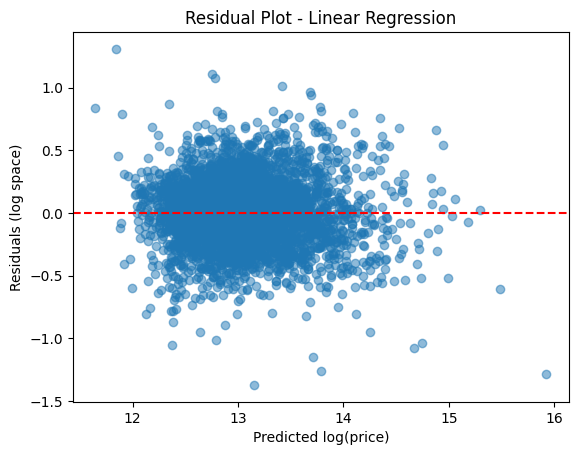

In [72]:
# Residual Plot
y_pred_lr = lr.predict(x_test)
residuals = y_test - y_pred_lr

plt.scatter(y_pred_lr, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted log(price)")
plt.ylabel("Residuals (log space)")
plt.title("Residual Plot - Linear Regression")
plt.show()